In [157]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

import neurolib.dashboard.data as data
from neurolib.models.aln import ALNModel
import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
from neurolib.utils import plotFunctions as plotFunc

In [44]:
with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

grid_resolution = layout.grid_resolution

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

In [100]:
##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]

def readcase(case_):
    
    global exc_, inh_, no_c_, both_c_
    global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
    global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4
    global d_x, d_y, cost_p_x, cost_p_y, cost_s_x, cost_e_x, cost_s_y, cost_e_y
    global d_xy_sum, d_xy, dx3, dy3, cost_xy, cost_xy_sum, costx3, costy3, len3_sum, len3sqrt
    
    readpath = '..' + os.sep + 'data' + os.sep + str(case_[:5]) + os.sep
    
    data_array = data.read_data(aln, readpath, case_)
    exc_, inh_, both_c_, no_c_ = data_array[0:4]
    exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
    exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_cost = control_data[3]
        
    d_x = []
    d_y = []
    d_xy_sum = []
    d_xy = []
    dx3 = []
    dy3 = []
    len3_sum = []
    len3sqrt = []
    
    if case_[0] == '0':
        for i in range(len(exc_1)):
            d_x.append(data.dist_right(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_low(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_3)):
            dx3.append(data.dist_right(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            dy3.append(data.dist_low(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            d_xy_sum.append(dx3[-1] + dy3[-1])
            len3_sum.append( np.abs(lenx_3[i]) + np.abs(leny_3[i]) )
            d_xy.append( np.sqrt( dx3[-1]**2 + dy3[-1]**2 ) )
            len3sqrt.append( np.sqrt( lenx_3[i]**2 + leny_3[i]**2  ))
    else:
        for i in range(len(exc_1)):
            d_x.append(data.dist_left(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_up(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_3)):
            dx3.append(data.dist_left(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            dy3.append(data.dist_up(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            d_xy_sum.append(dx3[-1] + dy3[-1])
            len3_sum.append( np.abs(lenx_3[i]) + np.abs(leny_3[i]) )
            d_xy.append( np.sqrt( dx3[-1]**2 + dy3[-1]**2 ) )
            len3sqrt.append( np.sqrt( lenx_3[i]**2 + leny_3[i]**2  ))
        
    cost_p_x = []
    cost_p_y = []
    cost_s_x = []
    cost_e_x = []
    cost_s_y = []
    cost_e_y = []
    
    cost_xy = []
    costx3 = []
    costy3 = []
    cost_xy_sum = []
    

    for i in range(len(d_x)):
        cost_p_x.append(cost1[i][0][0][0])
        cost_s_x.append(cost1[i][2][0][0])
        cost_e_x.append(cost1[i][1][0][0])
    for i in range(len(d_y)):
        cost_p_y.append(cost2[i][0][0][1])
        cost_s_y.append(cost2[i][2][0][1])
        cost_e_y.append(cost2[i][1][0][1])
    for i in range(len(dx3)):
        costx3.append(cost3[i][1][0][0])
        costy3.append(cost3[i][1][0][1])
        cost_xy_sum.append( costx3[-1] + costy3[-1] )
        cost_xy.append( np.sqrt( costx3[-1]**2 + costy3[-1]**2 ) )

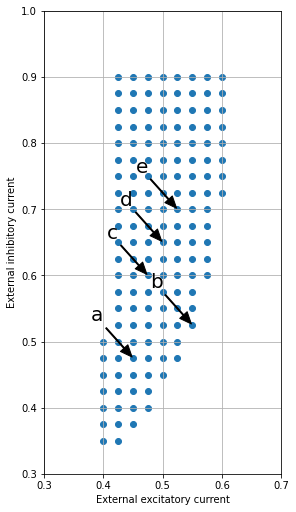

In [126]:
#FIG 1
dur = 400.
ind = [20, 35, 50, 65, 80]
str_ind = ['a', 'b', 'c', 'd', 'e']

fig1, ax = plt.subplots(constrained_layout=True, figsize = (4,7) )
ax.scatter(ext_exc, ext_inh)
ax.set_xlim(0.3, 0.7)
ax.set_ylim(0.3, 1.)

for i in range(len(ind)):
    x_ = ext_exc[ind[i]]
    y_ = ext_inh[ind[i]]
    ax.annotate(str_ind[i], xy=(x_, y_),  xycoords='data',
            xytext=(x_ - 0.05, y_ + 0.05), textcoords='data', fontsize=20,
            arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
            horizontalalignment='right', verticalalignment='bottom',
            )
    
ax.set_xlabel("External excitatory current")
ax.set_ylabel("External inhibitory current")
    
plt.savefig( os.path.join(os.getcwd(), 'FIG_1') )

task1
0 0.4500000000000001 0.4750000000000002
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
minimal cost =  4.42718872423572  for indices =  [ 8.  0. 40.  0.  0.  0.]
1 0.47500000000000014 0.6000000000000003
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
minimal cost =  5.692099788303073  for indices =  [ 8.  0. 40.  0.  0.  0.]
0 0.4500000000000001 0.4750000000000002
-------  0 0.4500000000000001 0.4750000000000002
1 0.47500000000000014 0.6000000000000003
-------  1 0.47500000000000014 0.6000000000000003
20 0.4500000000000001 0.4750000000000002
DC cost =  4.42718872423572
optimal cost =  3.425778651973082
early init cost =  3.3319269882798284
late init cost =  6.544055202849023


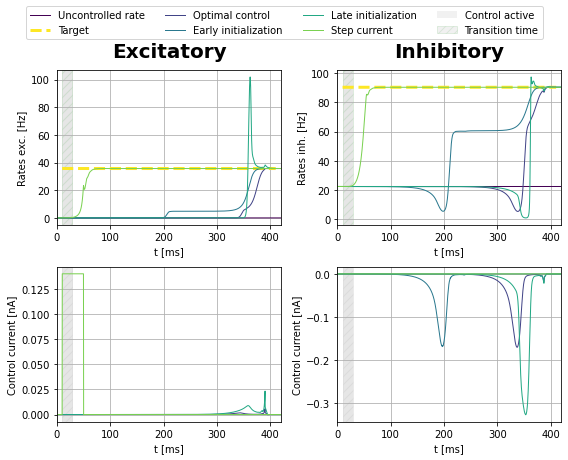

50 0.47500000000000014 0.6000000000000003
DC cost =  5.692099788303073
optimal cost =  15942.955436075114
early init cost =  6.294376914048247
late init cost =  6.544055202849023


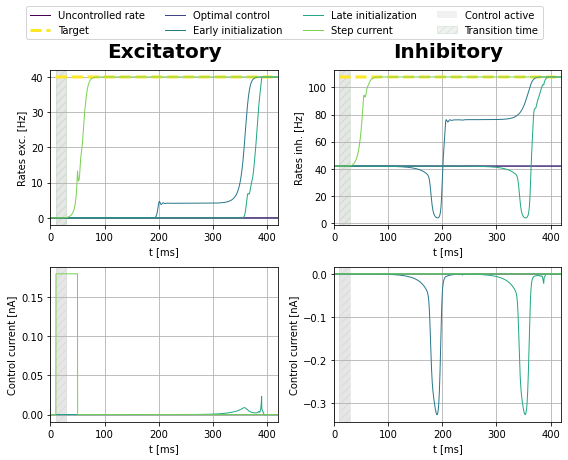

task2
0 0.4500000000000001 0.4750000000000002
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
minimal cost =  4.42718872423572  for indices =  [ 8.  0. 40.  0.  0.  0.]
1 0.47500000000000014 0.6000000000000003
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
8.0 0.0
minimal cost =  5.692099788303073  for indices =  [ 8.  0. 40.  0.  0.  0.]
0 0.4500000000000001 0.4750000000000002


FileNotFoundError: [Errno 2] No such file or directory: '..\\data_shift\\task2\\shift_-150\\control_init_01121.pickle'

In [181]:
# FIG 2, 3

data.set_parameters(aln)
dur = 400.
trans_time = 0.95

ind0 = [20, 50]
amp_range_exc = np.arange(8, 9., 1.)
start_range_exc = np.arange(0., 50., 10.)
amp_range_inh = np.arange(0, 1., 1.)
start_range_inh = np.arange(0., 1., 10.)
weights = [1., 0., 1.]

cases_ = ['00021', '01021', '10021', '11021']
casepath_ = ['00121', '01121', '10121', '11121']
tasks_ = ['task1', 'task2', 'task3', 'task4']

data.set_parameters(aln)

for c_ in range(len(cases_)):
    task = tasks_[c_]
    print(task)
    
    maxI = 3.
    if c_ in [2, 3]:
        maxI = -3.

    mincost = np.zeros(len(ind0))
    mincost[:] = 1000.
    minind = np.zeros(( len(ind0), 6 ))
    optcost = np.zeros(len(ind0))
    dist_ = np.zeros(len(ind0))
    dist_i = np.zeros(len(ind0))
    DC_control = [None] * len(ind0)
    
    opt_cntrl_0 = [None] * len(ind0)
    cost_node_0 = [None] * len(ind0)

    opt_cntrl_min = [None] * len(ind0)
    cost_node_min = [None] * len(ind0)

    opt_cntrl_plus = [None] * len(ind0)
    cost_node_plus = [None] * len(ind0)

    target_ = [None] * len(ind0)
    initVars = [None] * len(ind0)

    for i in range(len(ind0)):

        print(i, ext_exc[ind0[i]], ext_inh[ind0[i]])

        dist_[i] = data.dist_right(ext_exc[ind0[i]], ext_inh[ind0[i]], ext_exc, ext_inh, grid_resolution)
        dist_i[i] = data.dist_low(ext_exc[ind0[i]], ext_inh[ind0[i]], ext_exc, ext_inh, grid_resolution)
        
        if c_ in [2,3]:
            dist_[i] = data.dist_left(ext_exc[ind0[i]], ext_inh[ind0[i]], ext_exc, ext_inh, grid_resolution)
            dist_i[i] = data.dist_up(ext_exc[ind0[i]], ext_inh[ind0[i]], ext_exc, ext_inh, grid_resolution)
        
        opt_cntrl = control_data[2][ind0[i]][:,:,100:-100]
        opt_cost_node = control_data[4][ind0[i]]
        optcost[i] = opt_cost_node[0][0][0] + opt_cost_node[2][0][0]

        for a in amp_range_exc:
            for start in start_range_exc:
                for dur in np.arange(0, 80 - start, 20):
                    for a_i in amp_range_inh:
                        print(a, a_i)
                        for start_i in start_range_inh:
                            for dur_i in np.arange(0, 80 - start_i, 20):
                                cost_DC, control_DC = data.DC_trace(aln, ext_exc[ind0[i]], ext_inh[ind0[i]], start, dur,
                                                        [a * dist_[i], a_i * dist_i[i]], 400., case, trans_time, weights,
                                                         opt_cntrl, opt_cost_node, weights)
                                total_cost = ( weights[0] * cost_DC[0][0][0] + weights[1] * sum(cost_DC[1][0][:])
                                              + weights[2] * sum(cost_DC[2][0][:]) )
                                if total_cost < mincost[i]:
                                    minind[i] = [a, start, dur, a_i, start_i, dur_i]
                                    mincost[i] = total_cost
                                    DC_control[i] = control_DC.copy()

        print('minimal cost = ', mincost[i], ' for indices = ', minind[i])


    for i in range(len(ind0)):
        
        print(i, ext_exc[ind0[i]], ext_inh[ind0[i]])

        readpath = '..' + os.sep + 'data' + os.sep + casepath_[c_] + os.sep
        control_data = data.read_control(readpath, cases_[c_])
        for j in range(len(ind0)):
            opt_cntrl_0[j] = control_data[2][ind0[j]]
            cost_node_0[j] = control_data[4][ind0[j]]

        readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_-150'
        control_data = data.read_control(readpath, cases_[c_])
        for j in range(len(ind0)):
            opt_cntrl_min[j] = control_data[2][ind0[j]]
            cost_node_min[j] = control_data[4][ind0[j]]

        readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_+150'
        control_data = data.read_control(readpath, cases_[c_])
        for j in range(len(ind0)):
            opt_cntrl_plus[i] = control_data[2][ind0[j]]
            cost_node_plus[i] = control_data[4][ind0[j]]

        print("------- ", i, ext_exc[ind0[i]], ext_inh[ind0[i]])
        aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.
        aln.params.duration = 3000.
        control0 = aln.getZeroControl()
        control0 = functions.step_control(aln, maxI_ = maxI)
        aln.run(control=control0)

        target_rates = np.zeros((2))
        target_rates[0] = aln.rates_exc[0,-1] 
        target_rates[1] = aln.rates_inh[0,-1]

        control0 = functions.step_control(aln, maxI_ = -maxI)
        aln.run(control=control0)

        init_state_vars = np.zeros(( len(state_vars) ))
        for j in range(len(state_vars)):
            if aln.state[state_vars[j]].size == 1:
                init_state_vars[j] = aln.state[state_vars[j]][0]
            else:
                init_state_vars[j] = aln.state[state_vars[j]][0,-1]

        initVars[i] = init_state_vars

        aln.params.duration = 400.

        target_[i] = aln.getZeroTarget()
        target_[i][:,0,:] = target_rates[0]
        target_[i][:,1,:] = target_rates[1]


    aln.params.duration = dur
    t_sim = aln.params.duration
    t_sim_pre = 10.
    t_sim_post = 10.

    for i in range(len(ind0)):
        aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.

        print(ind0[i], ext_exc[ind0[i]], ext_inh[ind0[i]])
        setinit(initVars[i], aln)

        print('DC cost = ', mincost[i])
        ind_cost = 2
        if c_ in [1,3]:
            ind_cost = 1
        print('optimal cost = ', cost_node_0[i][0][0,0] + sum(cost_node_0[i][ind_cost][0,:]))
        print('early init cost = ', cost_node_min[i][0][0,0] + sum(cost_node_min[i][ind_cost][0,:]))
        print('late init cost = ', cost_node_plus[i][0][0,0] + sum(cost_node_plus[i][ind_cost][0,:]))
        
        DC_control_shape = np.zeros(( opt_cntrl_0[i].shape ))
        DC_control_shape[:,:,100:-100] = DC_control[i].copy()

        plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_min[i], opt_cntrl_plus[i], DC_control_shape],
                            [cost_node_0[i], cost_node_min[i], cost_node_plus[i]],
                            [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars[i],
                            target_[i], path_=os.getcwd(), filename_ = str(i) + '_' + task, shading = False,
                            transition_time_ = trans_time, labels_ = ['Optimal control', 'Early initialization',
                            'Late initialization', 'Step current'],
                            precision_variables_ = [0], print_cost_ = False)
        plt.show()

task1
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
20 0.4500000000000001 0.4750000000000002
optimal cost =  3.425778651973082
shift by -20 ms cost =  16.094063147952937
shift by +20 ms cost =  3.410852101163082


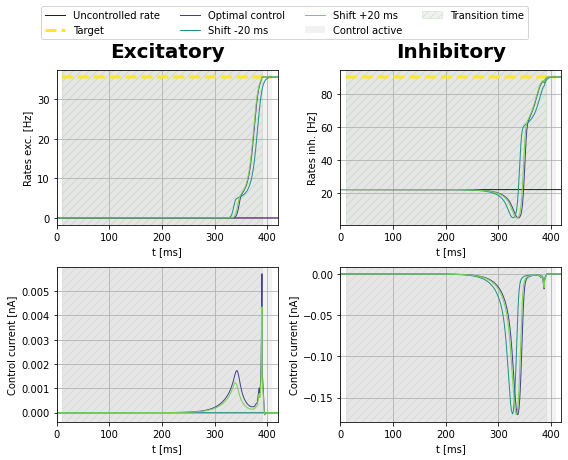

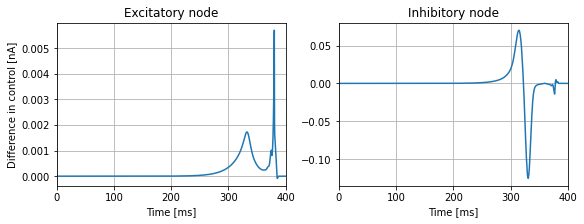

50 0.47500000000000014 0.6000000000000003
optimal cost =  15942.955436075114
shift by -20 ms cost =  10.088565260425316
shift by +20 ms cost =  6.397885625438294


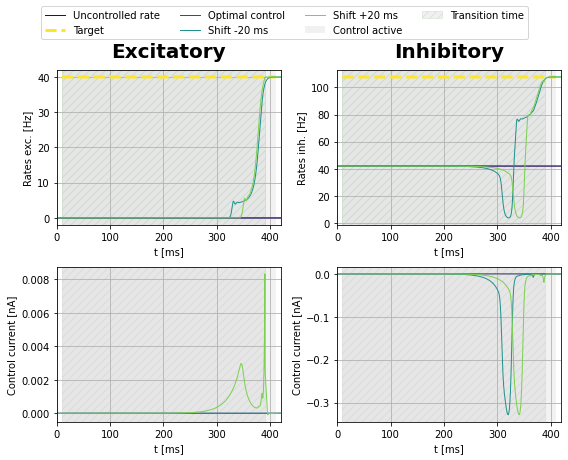

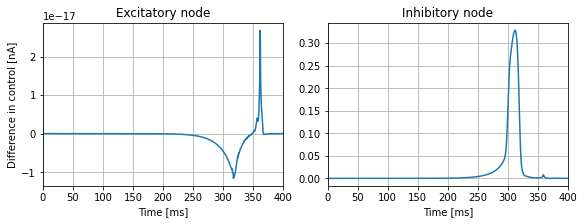

task2


FileNotFoundError: [Errno 2] No such file or directory: '..\\data_shift\\task2\\shift_-20\\control_init_01121.pickle'

In [190]:
# FIG 4, 5
# task 1

ind0 = [20, 50]

cases_ = ['00021', '01021', '10021', '11021']
casepath_ = ['00121', '01121', '10121', '11121']
tasks_ = ['task1', 'task2', 'task3', 'task4']
dur = 400.

for c_ in range(len(cases_)):
    task = tasks_[c_]
    print(task)
    
    opt_cntrl_0 = [None] * len(ind0)
    cost_node_0 = [None] * len(ind0)

    opt_cntrl_min20 = [None] * len(ind0)
    cost_node_min20 = [None] * len(ind0)

    opt_cntrl_plus20 = [None] * len(ind0)
    cost_node_plus20 = [None] * len(ind0)

    target_ = [None] * len(ind0)
    initVars = [None] * len(ind0)

    readpath = '..' + os.sep + 'data' + os.sep + casepath_[c_] + os.sep
    control_data = data.read_control(readpath, cases_[c_])
    for i in range(len(ind0)):
        opt_cntrl_0[i] = control_data[2][ind0[i]]
        cost_node_0[i] = control_data[4][ind0[i]]

    readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_-20'
    control_data = data.read_control(readpath, cases_[c_])
    for i in range(len(ind0)):
        opt_cntrl_min20[i] = control_data[2][ind0[i]]
        cost_node_min20[i] = control_data[4][ind0[i]]

    readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_+20'
    control_data = data.read_control(readpath, cases_[c_])
    for i in range(len(ind0)):
        opt_cntrl_plus20[i] = control_data[2][ind0[i]]
        cost_node_plus20[i] = control_data[4][ind0[i]]

    data.set_parameters(aln)

    for i in range(len(ind0)):

        print("------- ", i, ext_exc[ind0[i]], ext_inh[ind0[i]])
        aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.
        aln.params.duration = 3000.
        control0 = aln.getZeroControl()
        control0 = functions.step_control(aln, maxI_ = 3.)
        aln.run(control=control0)

        target_rates = np.zeros((2))
        target_rates[0] = aln.rates_exc[0,-1] 
        target_rates[1] = aln.rates_inh[0,-1]

        control0 = functions.step_control(aln, maxI_ = -3.)
        aln.run(control=control0)

        init_state_vars = np.zeros(( len(state_vars) ))
        for j in range(len(state_vars)):
            if aln.state[state_vars[j]].size == 1:
                init_state_vars[j] = aln.state[state_vars[j]][0]
            else:
                init_state_vars[j] = aln.state[state_vars[j]][0,-1]

        initVars[i] = init_state_vars

        aln.params.duration = dur

        target_[i] = aln.getZeroTarget()
        target_[i][:,0,:] = target_rates[0]
        target_[i][:,1,:] = target_rates[1]

    aln.params.duration = dur
    t_sim = aln.params.duration
    t_sim_pre = 10.
    t_sim_post = 10.

    for i in range(len(ind0)):
        aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.

        print(ind0[i], ext_exc[ind0[i]], ext_inh[ind0[i]])
        setinit(initVars[i], aln)
        
        ind_cost = 2
        if c_ in [1,3]:
            ind_cost = 1
        print('optimal cost = ', cost_node_0[i][0][0,0] + sum(cost_node_0[i][ind_cost][0,:]))
        print('shift by -20 ms cost = ', cost_node_min20[i][0][0,0] + sum(cost_node_min20[i][ind_cost][0,:]))
        print('shift by +20 ms cost = ', cost_node_plus20[i][0][0,0] + sum(cost_node_plus20[i][ind_cost][0,:]))

        plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_min20[i], opt_cntrl_plus20[i]],
                            [cost_node_0[i], cost_node_min20[i], cost_node_plus20[i]],
                            [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars[i],
                            target_[i], path_=os.getcwd(), filename_ = 'FIG_3_' + str(i) + '_' + task, shading = False,
                            transition_time_ = 0.95, labels_ = ['Optimal control', 'Shift -20 ms', 'Shift +20 ms'],
                            precision_variables_ = [0], print_cost_ = False)
        plt.show()

        fig3, ax = plt.subplots(1,2, constrained_layout=True, figsize = (8,3) )
        time_ = np.arange(0, dur + aln.params.dt, aln.params.dt )
        diff_min20 = np.zeros(( opt_cntrl_0[i][0,:,100:-100].shape ))
        diff_plus20 = diff_min20.copy()
        diff_min20[0,20:] = opt_cntrl_0[i][0,0,120:4101] - opt_cntrl_min20[i][0,0,100:4081]
        diff_min20[1,20:] = opt_cntrl_0[i][0,1,120:4101] - opt_cntrl_min20[i][0,1,100:4081]
        diff_plus20[0,20:] = opt_cntrl_0[i][0,0,100:4081] - opt_cntrl_min20[i][0,0,120:4101]
        diff_plus20[1,20:] = opt_cntrl_0[i][0,1,100:4081] - opt_cntrl_min20[i][0,1,120:4101]
        ax[0].plot(time_, diff_min20[0,:]/5.)
        ax[1].plot(time_, diff_min20[1,:]/5.)

        ax[0].set_xlim(0, dur)
        ax[1].set_xlim(0,dur)
        ax[0].set_title('Excitatory node')
        ax[1].set_title('Inhibitory node')
        ax[0].set_xlabel("Time [ms]")
        ax[1].set_xlabel("Time [ms]")
        ax[0].set_ylabel("Difference in control [nA]")
        plt.savefig( os.path.join(os.getcwd(), 'FIG_4_' + task + '_' + str(i)) )
        plt.show()

    # plot difference

In [136]:
# FIG 4, 5
# task 2

ind0 = [20, 50]

opt_cntrl_0 = [None] * len(ind0)
cost_node_0 = [None] * len(ind0)

opt_cntrl_min20 = [None] * len(ind0)
cost_node_min20 = [None] * len(ind0)

opt_cntrl_plus20 = [None] * len(ind0)
cost_node_plus20 = [None] * len(ind0)

target_ = [None] * len(ind0)
initVars = [None] * len(ind0)

case = '01021'
casepath = '01121'
readpath = '..' + os.sep + 'data' + os.sep + casepath + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind0)):
    opt_cntrl_0[i] = control_data[2][ind0[i]]
    cost_node_0[i] = control_data[4][ind0[i]]

readpath = '..' + os.sep + 'data_shift' + os.sep + 'task1' + os.sep + 'shift_-20'
control_data = data.read_control(readpath, case)
for i in range(len(ind0)):
    opt_cntrl_min20[i] = control_data[2][ind0[i]]
    cost_node_min20[i] = control_data[4][ind0[i]]

readpath = '..' + os.sep + 'data_shift' + os.sep + 'task1' + os.sep + 'shift_+20'
control_data = data.read_control(readpath, case)
for i in range(len(ind0)):
    opt_cntrl_plus20[i] = control_data[2][ind0[i]]
    cost_node_plus20[i] = control_data[4][ind0[i]]

data.set_parameters(aln)

for i in range(len(ind0)):
    
    print("------- ", i, ext_exc[ind0[i]], ext_inh[ind0[i]])
    aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target_[i] = aln.getZeroTarget()
    target_[i][:,0,:] = target_rates[0]
    target_[i][:,1,:] = target_rates[1]
    
    
aln.params.duration = dur
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

for i in range(len(ind0)):
    aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.
    
    print(ind0[i], ext_exc[ind0[i]], ext_inh[ind0[i]])
    setinit(initVars[i], aln)
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_min20[i], opt_cntrl_plus20[i]],
                                  [cost_node_0[i], cost_node_min20[i], cost_node_plus20[i]],
                         [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars[i],
                         target_[i], path_=os.getcwd(), filename_ = str(i) + '_100', shading = False, transition_time_ = 0.95,
                         labels_ = ['Optimal control', 'Shift -20 ms', 'Shift +20 ms'],
                         precision_variables_ = [0], print_cost_ = False)
    plt.show()
    
    fig3, ax = plt.subplots(1,2, constrained_layout=True, figsize = (8,3) )
    time_ = np.arange(0, dur + aln.params.dt, aln.params.dt )
    diff_min20 = np.zeros(( opt_cntrl_0[i][0,:,100:-100].shape ))
    diff_plus20 = diff_min20.copy()
    diff_min20[0,20:] = opt_cntrl_0[i][0,0,120:4101] - opt_cntrl_min20[i][0,0,100:4081]
    diff_min20[1,20:] = opt_cntrl_0[i][0,1,120:4101] - opt_cntrl_min20[i][0,1,100:4081]
    diff_plus20[0,20:] = opt_cntrl_0[i][0,0,100:4081] - opt_cntrl_min20[i][0,0,120:4101]
    diff_plus20[1,20:] = opt_cntrl_0[i][0,1,100:4081] - opt_cntrl_min20[i][0,1,120:4101]
    ax[0].plot(time_, diff_min20[0,:]/5.)
    ax[1].plot(time_, diff_min20[1,:]/5.)
    
    ax[0].set_xlim(0, dur)
    ax[1].set_xlim(0,dur)
    ax[0].set_title('Excitatory node')
    ax[1].set_title('Inhibitory node')
    ax[0].set_xlabel("Time [ms]")
    ax[1].set_xlabel("Time [ms]")
    ax[0].set_ylabel("Difference in control [nA]")
    plt.savefig( os.path.join(os.getcwd(), 'FIG_4_task1_' + str(i)) )
    
# plot difference

FileNotFoundError: [Errno 2] No such file or directory: '..\\data_shift\\task1\\shift_-20\\control_init_01121.pickle'

task 1
case =  00021
task 2
case =  01021
task 3
case =  10021
task 4
case =  11021


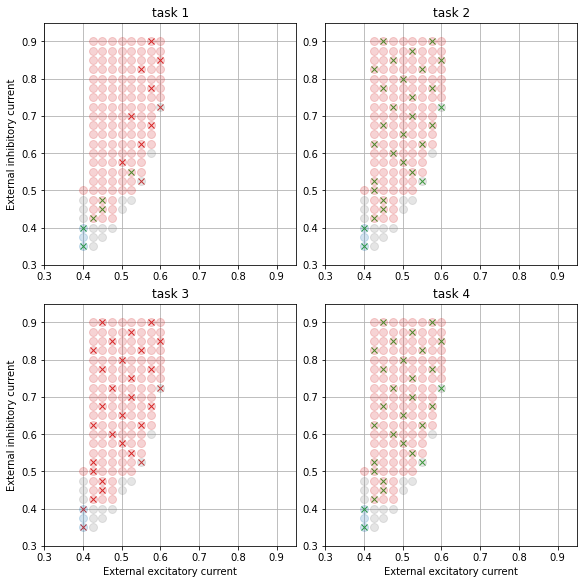

In [59]:
# fig 6, 7, 8, 9

fig7, ax = plt.subplots(2,2, constrained_layout=True, figsize = (8,8) )

titles = [r'task 1', r'task 2', 'task 3', 'task 4']

cases = ['00021', '01021', '10021', '11021']

alpha_val = 0.2

for k in range(len(cases)):
    print(titles[k])
    print("case = ", cases[k])
    readcase(cases[k])
    cost_index = np.zeros(( len(ext_exc), 4))
    
    ind_x = 0
    ind_y = 0
    
    if k == 1:
        ind_y = 1
    elif k == 2:
        ind_x = 1
    elif k == 3:
        ind_x = 1
        ind_y = 1

    for i in range(len(ext_exc)):
        cost_index[i,0] = i
        for j in range(len(exc_)):
            if exc_[j] == i:
                cost_index[i,1] = cost1[j][0][0][0] + cost1[j][2][0][0]
                if cost_index[i,1] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,1])
        for j in range(len(inh_)):
            if inh_[j] == i:
                cost_index[i,2] = cost2[j][0][0][0] + cost2[j][2][0][1]
                if cost_index[i,2] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,2])
        for j in range(len(both_c_)):
            if both_c_[j] == i:
                cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                if cost_index[i,3] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,3])

    for i in range(cost_index.shape[0]):
        
        if cost_index[i,1] != 0. and cost_index[i,2] != 0. and cost_index[i,3] != 0.:
            if cost_index[i,1] < cost_index[i,2] and cost_index[i,1] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,2] < cost_index[i,1] and cost_index[i,2] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
            elif cost_index[i,2] < cost_index[i,1] and cost_index[i,2] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
            elif cost_index[i,3] < cost_index[i,1] and cost_index[i,3] < cost_index[i,2]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=green)
        elif cost_index[i,1] != 0. and cost_index[i,2] != 0.:
            if cost_index[i,1] < cost_index[i,2]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,2] < cost_index[i,1]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0. and cost_index[i,3] != 0.:
            if cost_index[i,1] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,3] < cost_index[i,1]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=green)
        elif cost_index[i,3] != 0. and cost_index[i,2] != 0.:
            if cost_index[i,3] < cost_index[i,2]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=green)
            elif cost_index[i,2] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0.:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
        elif cost_index[i,2] != 0.:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,3] != 0.:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=green)


        dist_x = data.dist_right(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
        dist_y = data.dist_low(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)

        if (dist_x - dist_y) < - 1e-4:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=exc_red)
        elif (dist_x - dist_y) > 1e-4:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=inh_blue)
        else:
            #print("apparently same distance: ", i, dist_x, dist_y)
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color='grey')

    ax[ind_x,ind_y].set_xlim(0.3, 0.95)
    ax[ind_x,ind_y].set_ylim(0.3, 0.95)
    
    ax[ind_x,ind_y].set_title(titles[k])    
    
ax[1,0].set_xlabel("External excitatory current")
ax[1,1].set_xlabel("External excitatory current")
ax[0,0].set_ylabel("External inhibitory current")
ax[1,0].set_ylabel("External inhibitory current")
    
plt.savefig(os.path.join(os.getcwd(), 'FIG_6_7_8_9'))

#print(exc_, inh_, both_c_, no_c_)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
---------- 00021 20
optimal cost =  3.425778651973082


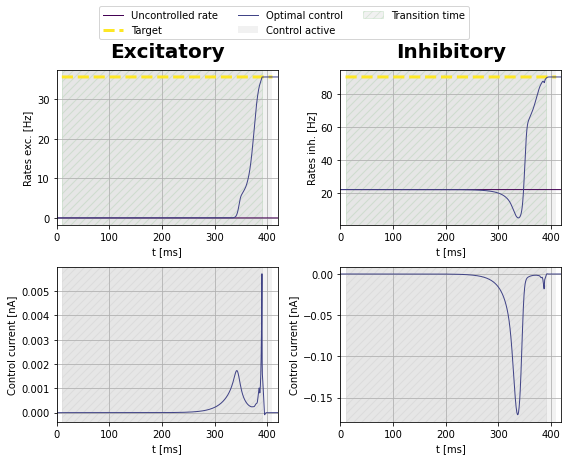

---------- 00021 50
optimal cost =  0.416136958029157


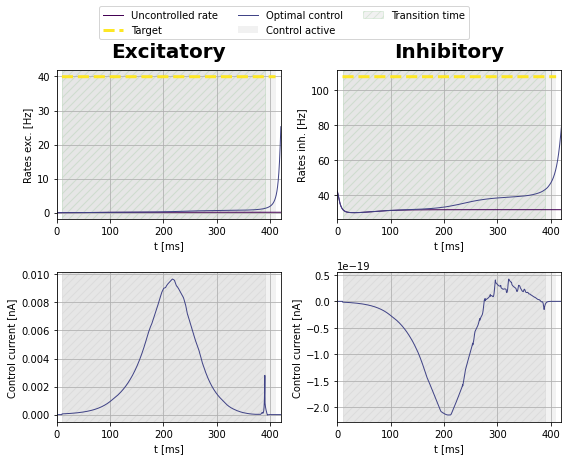

---------- 01021 20
optimal cost =  3.7458271981542905


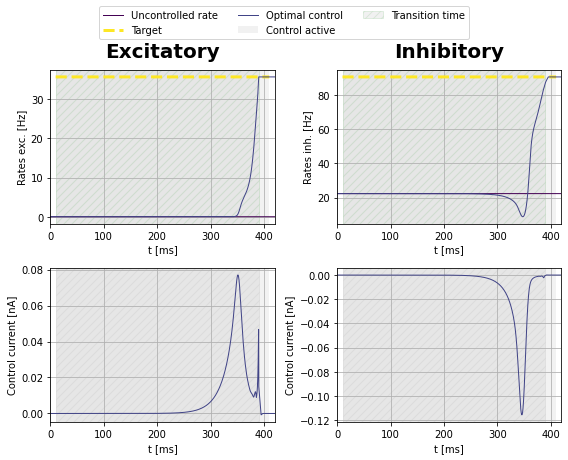

---------- 01021 50
optimal cost =  0.07263982339913139


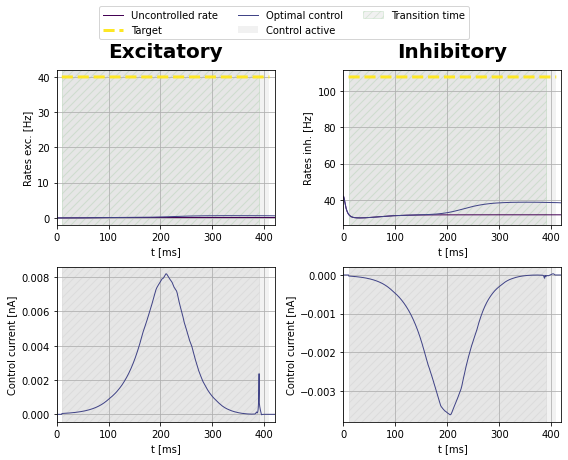

---------- 10021 20
optimal cost =  2.1940148358512084


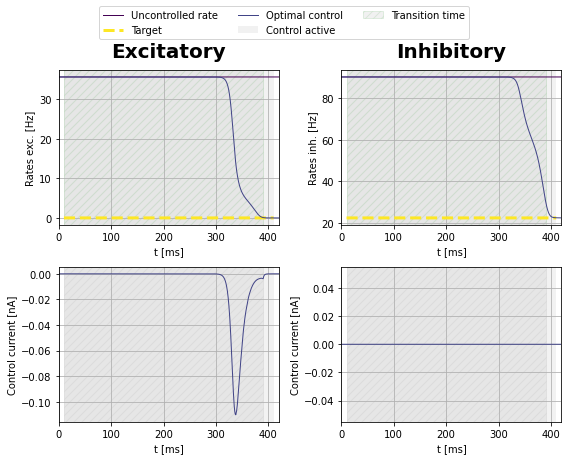

---------- 10021 50
optimal cost =  5.092714673084245


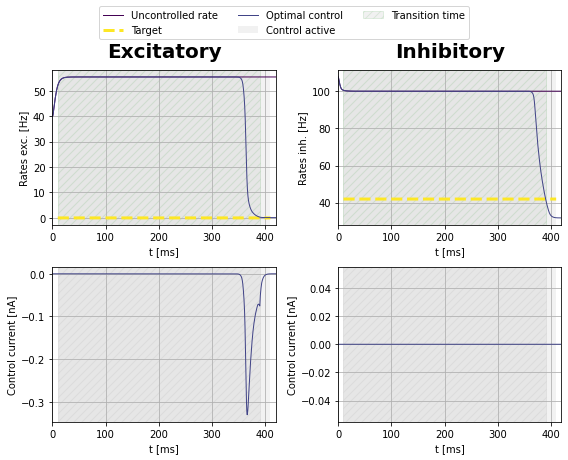

---------- 11021 20
optimal cost =  2.3878619893316353


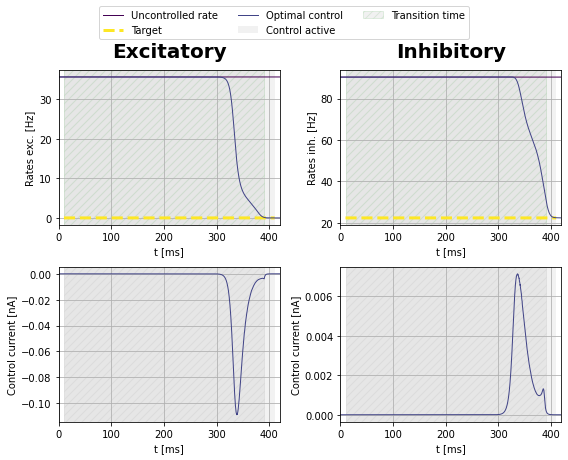

---------- 11021 50
optimal cost =  12.801030460157238


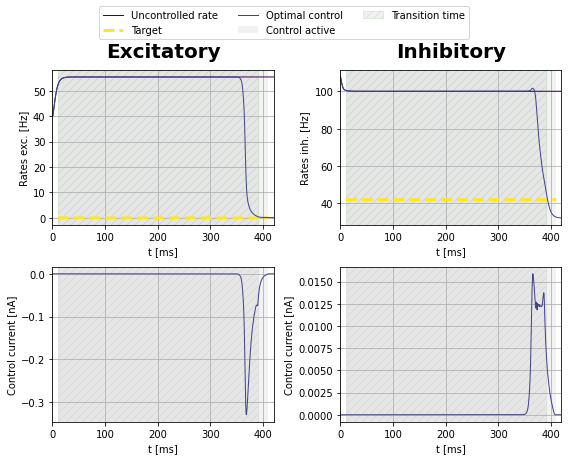

In [193]:
# FIG 8,9
weights = [1., 0., 1.]
ind_0 = [20,50]

case = ['00021', '01021', '10021', '11021']

opt_cntrl_0 = [None] * (len(ind_0) * len(case))
cost_node_0 = [None] * (len(ind_0) * len(case))

target_0 = [None] * (len(ind_0) * len(case))
initVars_0 = [None] * (len(ind_0) * len(case))

data.set_parameters(aln)

for j in range(len(case)):
    
    readpath = '..' + os.sep + 'data' + os.sep + case[j] + os.sep
    control_data = data.read_control(readpath, case[j])
    
    for i in range(len(ind_0)):
        opt_cntrl_0[j*2 + i] = control_data[2][ind[i]]
        cost_node_0[j*2 + i] = control_data[4][ind[i]]

        print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
        aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.

        aln.params.duration = 3000.
        control0 = aln.getZeroControl()
        maxI = 3.
        if j in [2,3]:
            maxI = -3
        control0 = functions.step_control(aln, maxI_ = maxI)
        aln.run(control=control0)

        target_rates = np.zeros((2))
        target_rates[0] = aln.rates_exc[0,-1] 
        target_rates[1] = aln.rates_inh[0,-1]

        control0 = functions.step_control(aln, maxI_ = -maxI)
        aln.run(control=control0)

        init_state_vars = np.zeros(( len(state_vars) ))
        for k in range(len(state_vars)):
            if aln.state[state_vars[k]].size == 1:
                init_state_vars[k] = aln.state[state_vars[k]][0]
            else:
                init_state_vars[k] = aln.state[state_vars[k]][0,-1]

        initVars_0[j*2 + i] = init_state_vars

        aln.params.duration = 400.

        target_0[j*2 + i] = aln.getZeroTarget()
        target_0[j*2 + i][:,0,:] = target_rates[0]
        target_0[j*2 + i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

names = ['FIG_8', 'FIG_9', 'FIG_10', 'FIG_11', 'FIG_12', 'FIG_13', 'FIG_14', 'FIG_15']

for j in range(len(case)):
    for i in range(len(ind_0)):
        aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.

        filename = names[j*2 + i]
        
        print('----------', case[j], ind_0[i])
        ind_cost = 2
        if j in [1,3]:
            ind_cost = 1            
        print('optimal cost = ', cost_node_0[j*2 + i][0][0,0] + sum(cost_node_0[j*2 + i][ind_cost][0,:]))

        plotFunc.plot_control_current(aln, [opt_cntrl_0[j*2 + i]],
                            [cost_node_0[j*2 + i]],
                            [weights], t_sim, t_sim_pre, t_sim_post, initVars_0[j*2 + i],
                            target_0[j*2 + i], path_=os.getcwd(), filename_ = filename, shading = False,
                            transition_time_ = 0.95,
                            labels_ = ['Optimal control'],
                            precision_variables_ = [0], print_cost_ = False)
        plt.show()

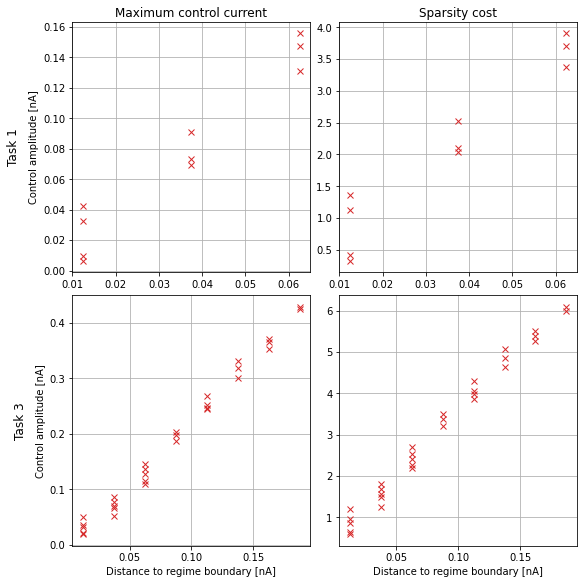

In [66]:
# FIG 16, 18

fig5, ax = plt.subplots(2, 2, constrained_layout=True, figsize = (8,8) )
    
readcase('00021')
ax[0,0].plot(d_x, np.abs(lenx_1), 'x', color=exc_red, markersize=6)
ax[0,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[0,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
ax[0,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)

readcase('10021')
ax[1,0].plot(d_x, np.abs(lenx_1), 'x', color=exc_red, markersize=6)
ax[1,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[1,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
ax[1,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)

ax[1,0].set_xlabel("Distance to regime boundary [nA]")
ax[1,1].set_xlabel("Distance to regime boundary [nA]")
ax[0,0].set_ylabel("Control amplitude [nA]")
ax[1,0].set_ylabel("Control amplitude [nA]")

cols = ['Maximum control current', 'Sparsity cost']
rows = ['Task 1', 'Task 3']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)

plt.savefig( os.path.join(os.getcwd(), 'FIG_16_18') )
plt.show()

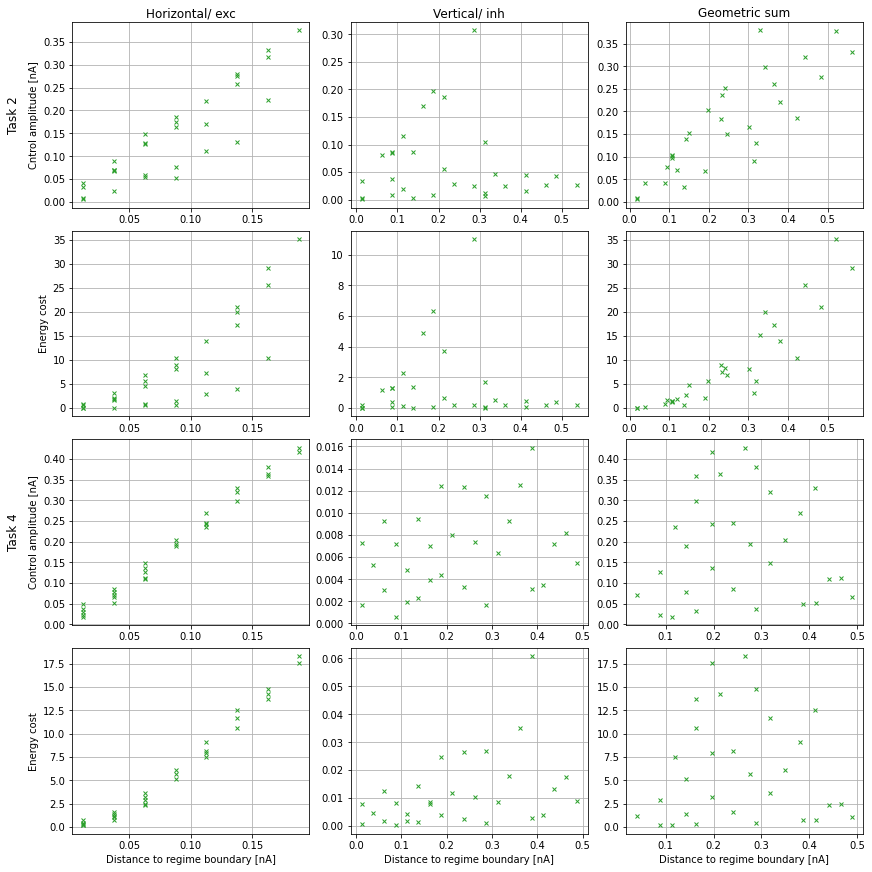

In [67]:
fig5b, ax = plt.subplots(4,3, constrained_layout=True, figsize = (12,12) )

color_array = [exc_red, inh_blue, green, exc_red, inh_blue, green]
range_1 = ['01000', '01010', '01020']
range_2 = ['01001', '01011', '01021']#, '01031', '01041', '01051']
range_3 = ['01100', '01110', '01120']
range_4 = ['01101', '01111', '01121']
range_5 = ['01131', '01141', '01151']

#########################################
readcase('01021')
ax[0,0].plot(dx3, np.abs(lenx_3), 'x', color=green, markersize=4)
ax[0,1].plot(dy3, np.abs(leny_3), 'x', color=green, markersize=4)
ax[0,2].plot(d_xy, len3sqrt, 'x', color=green, markersize=4)
    
ax[1,0].plot(dx3, costx3, 'x', color=green, markersize=4)
ax[1,1].plot(dy3, costy3, 'x', color=green, markersize=4)
ax[1,2].plot(d_xy, cost_xy, 'x', color=green, markersize=4)

readcase('11021')
ax[2,0].plot(dx3, np.abs(lenx_3), 'x', color=green, markersize=4)
ax[2,1].plot(dy3, np.abs(leny_3), 'x', color=green, markersize=4)
ax[2,2].plot(d_xy, len3sqrt, 'x', color=green, markersize=4)
    
ax[3,0].plot(dx3, costx3, 'x', color=green, markersize=4)
ax[3,1].plot(dy3, costy3, 'x', color=green, markersize=4)
ax[3,2].plot(d_xy, cost_xy, 'x', color=green, markersize=4)

ax[3,0].set_xlabel("Distance to regime boundary [nA]")
ax[3,1].set_xlabel("Distance to regime boundary [nA]")
ax[3,2].set_xlabel("Distance to regime boundary [nA]")
ax[0,0].set_ylabel("Cntrol amplitude [nA]")
ax[1,0].set_ylabel("Energy cost")
ax[2,0].set_ylabel("Control amplitude [nA]")
ax[3,0].set_ylabel("Energy cost")

cols = ['Horizontal/ exc', 'Vertical/ inh', 'Geometric sum']
rows = ['Task 2', '', 'Task 4', '']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)

plt.savefig( os.path.join(os.getcwd(), 'FIG_17_19.png') )
plt.show()